# **EDA Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [108]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data
/content/gdrive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [109]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [110]:
# <Student to fill this section>
import numpy as np
import re

### 0.d Import Packages

In [111]:
# <Student to fill this section>
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
import seaborn as sns

---
## A. Project Description


In [112]:
# <Student to fill this section>
group_name = "Group 24"
student_name = "Yuyang Chen"
student_id = "13417454"

In [113]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [114]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [115]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Data Understanding

### B.1   Load Dataset

In [116]:
# Do not modify this code
try:
  df = pd.read_csv(folder_path / "customer_address.csv")
except Exception as e:
  print(e)

### B.2 Explore Dataset

> You can add more cells in this section

In [117]:
# display head
df.head()

,Unnamed: 0,customer_id,street,type,suburb,postcode,full_address
0,0,d36b3782-86b2-4f7e-97f4-19751cf735b1,Chandler Gardens,Park,Smithchester,6683.0,"Suite 159 4 Chandler Gardens Park, Smithcheste..."
1,1,c16a23a6-c001-4846-b16a-e681692d861b,Tara Alleyway,Avenue,Mayberg,2629.0,"Flat 31 247 Tara Alleyway Avenue, Mayberg QLD..."
2,2,f044a91f-3eeb-4342-9c96-2be28927a8a9,Sullivan Reserve,Reach,Vegamouth,2790.0,"Level 5 591 Sullivan Reserve Reach, Vegamouth ..."
3,3,36096d1a-4f30-4c1c-8453-3db3ea81692c,Daniel Parade,Break,East Matthewfurt,NaN,"Unit 09 7 Daniel Parade Break, East Matthewfur..."
4,4,7484593e-4ff2-44d6-9de6-7e3bd9fe8b19,Charles Driveway,River,New Shannon,2611.0,"720/460 Charles Driveway River, New Shannon W..."


In [118]:
#display tail
df.tail()

,Unnamed: 0,customer_id,street,type,suburb,postcode,full_address
11360,11360,668dd5e8-8149-4dd7-bed3-574554a742c2,Peter Riviera,Glen,New Keithmouth,2910.0,"91/5 Peter Riviera Glen, New Keithmouth WA, ..."
11361,11361,9c685673-82b6-4ea8-97b1-66602847d340,Myers Expressway,Roadside,Hillbury,2664.0,"Level 9 280 Myers Expressway Roadside, Hillbur..."
11362,11362,98f94553-e5c9-4732-87ad-0aa7f99ec659,Powers Mount,Path,Garciaton,8214.0,"Apt. 882 134 Powers Mount Path, Garciaton QLD..."
11363,11363,117eddb6-5868-4bd2-a7a5-e1588055e0b4,Gomez Port,Path,Adamsburgh,NaN,"Flat 44 13 Gomez Port Path, Adamsburgh NT, 0935"
11364,11364,714a22ce-bb0d-40b4-82e7-c2fc8de0977a,Crawford Chase,Promenade,Tracimouth,919.0,NaN


In [119]:
#display shape
df.shape

(11365, 7)

In [120]:
#display info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11365 entries, 0 to 11364
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    11365 non-null  int64  
 1   customer_id   11365 non-null  object 
 2   street        11365 non-null  object 
 3   type          11365 non-null  object 
 4   suburb        9904 non-null   object 
 5   postcode      7530 non-null   float64
 6   full_address  8690 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 621.7+ KB


In [121]:
#display descriptive info
df.describe()

,Unnamed: 0,postcode
count,11365.000000,7530.000000
mean,5682.000000,3170.034130
std,3280.937239,1810.136976
min,0.000000,200.000000
25%,2841.000000,2600.000000
50%,5682.000000,2693.000000
75%,8523.000000,2969.000000
max,11364.000000,9992.000000


In [122]:
# <Student to fill this section>
dataset_insights = """

- Key geographic identifiers such as street, type, suburb, postcode, and a derived full_address field are included among the 11,365 customer records.

- These records are spread across 7 columns in the customer_address dataset.

- The majority of fields are filled, but there are notable gaps: 13% of suburb entries and 22% of postcode values are missing.

- Missing data in these fields could impact region-based analyses if not properly imputed or filtered.
- Only 76% of entries contain complete address strings, suggesting potential missing or inconsistent address formatting.
- The postcode field has a range from 200 to 9992, indicating possible anomalies.

- The dataset includes an Unnamed: 0 column that is likely a redundant index and may be removed during data cleaning.

"""

In [123]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.3 Explore Feature of Interest 1: Most Common Suburbs

> You can add more cells in this section

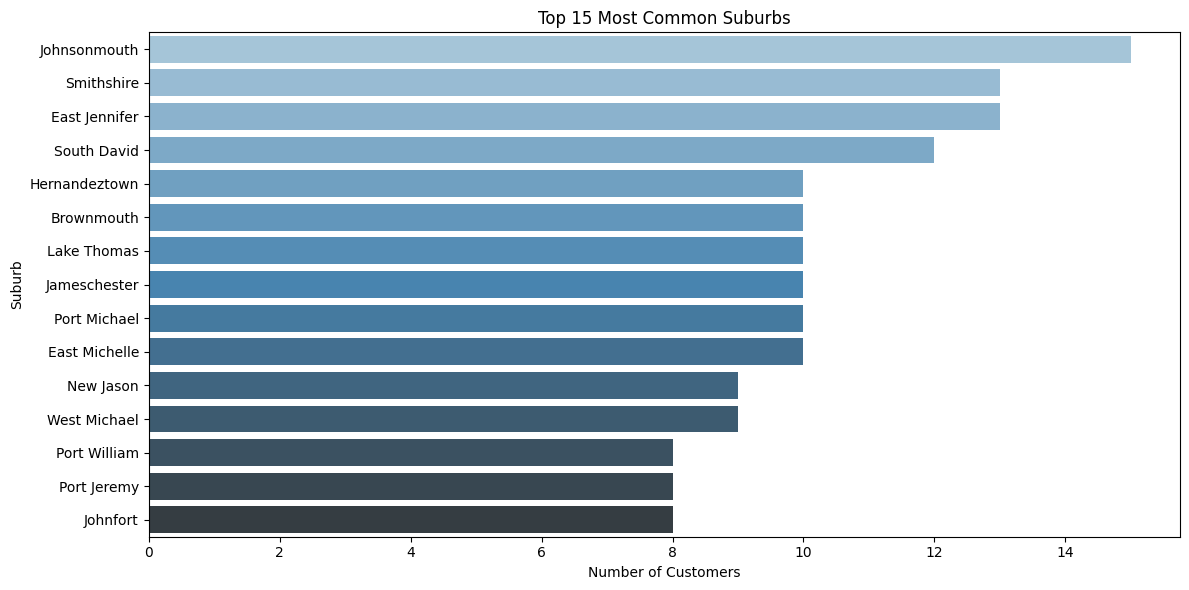

In [124]:
# generate bar chart for top 15 most common suburbs
plt.figure(figsize=(12,6))
top_suburbs = df['suburb'].value_counts().head(15)
sns.barplot(x=top_suburbs.values, y=top_suburbs.index, palette='Blues_d')
plt.title('Top 15 Most Common Suburbs')
plt.xlabel('Number of Customers')
plt.ylabel('Suburb')
plt.tight_layout()
plt.show()


In [125]:
# <Student to fill this section>
feature1_insights = """

- The top three suburbs with the highest customer concentrations are Johnsonmouth, Smithshire, and East Jennifer.
- Each of these suburbs has more than 12 entries in the customer_address dataset, indicating potential customer clusters.
- Approximately 13% of the dataset, or 1,461 entries, are missing suburb values out of a total of 11,365 records.
- If the missing geographic data is not properly addressed through imputation or filtering, it could affect targeting strategies and spatial analyses.

"""

In [126]:
# Do not modify this code
print_tile(size="h3", key='feature1_insights', value=feature1_insights)

### B.4 Explore Feature of Interest 2: Postcode

> You can add more cells in this section

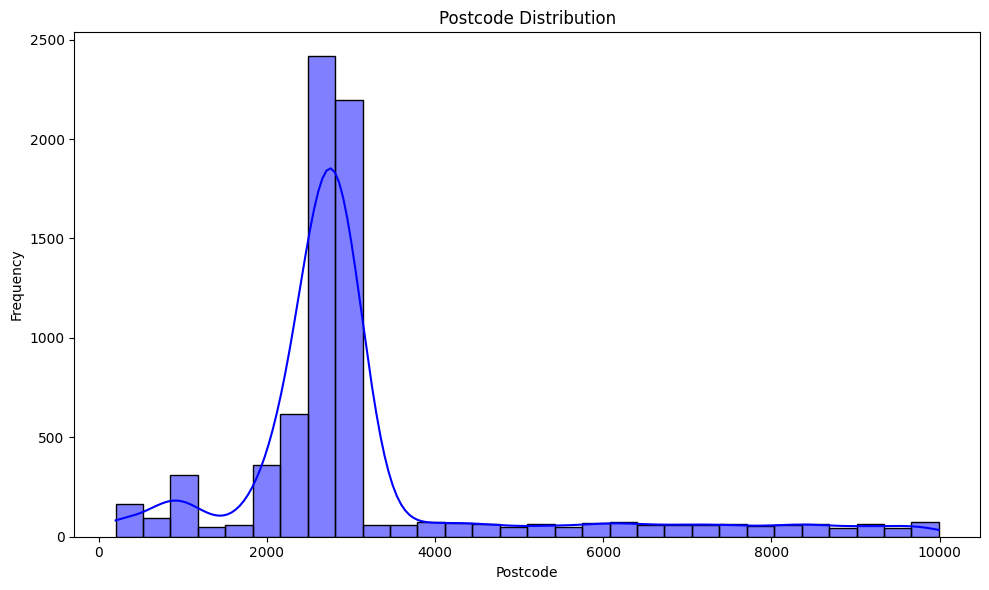

In [127]:
# postcode histogram
plt.figure(figsize=(10,6))
sns.histplot(df['postcode'], bins=30, kde=True, color='blue')
plt.title('Postcode Distribution')
plt.xlabel('Postcode')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [128]:
# <Student to fill this section>
feature_2_insights = """

- The value minimum is 200 while the maximum is 9992.
- Spike seen at between 2000 and 4000, signifying majority of customer in two States.
- Approximately 13% of the dataset, or 1,461 entries, are missing suburb values out of a total of 11,365 records.
- If the missing geographic data is not properly addressed through imputation or filtering, it could affect targeting strategies and spatial analyses.

"""

In [129]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.5 Explore Feature of Interest n

> You can add more cells in this section

In [130]:
# <Student to fill this section>

In [131]:
# <Student to fill this section>
feature_n_insights = """
"""

In [132]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## C. Data Cleaning

### C.1 Copy Dataset

In [133]:
# Do not modify this code
df_clean = df.copy()
try:
  df_clean = df.copy()
except Exception as e:
  print(e)

### C.2 Fixing "Excessive values"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [ ]:
# drop redundant column
df_clean = df_clean.drop(columns=["Unnamed: 0"])

In [135]:
# drop duplicates
df_clean = df_clean.drop_duplicates()

In [136]:
# Display summary
print(df_clean.info())
print(df_clean.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 7845 entries, 0 to 11364
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   7845 non-null   object 
 1   street        7845 non-null   object 
 2   type          7845 non-null   object 
 3   suburb        7072 non-null   object 
 4   postcode      5695 non-null   float64
 5   full_address  6338 non-null   object 
dtypes: float64(1), object(5)
memory usage: 429.0+ KB
None
          postcode
count  5695.000000
mean   3160.762950
std    1800.424153
min     200.000000
25%    2600.000000
50%    2692.000000
75%    2967.000000
max    9992.000000


In [137]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Dropping unnamed column for cleanliness. Drop duplicates if there are any.
"""

In [138]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### C.3 Fixing Empty Values, as much as I can

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [165]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7845 entries, 0 to 11364
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   7845 non-null   object 
 1   street        7845 non-null   object 
 2   type          7845 non-null   object 
 3   suburb        7072 non-null   object 
 4   postcode      5695 non-null   float64
 5   full_address  6338 non-null   object 
dtypes: float64(1), object(5)
memory usage: 429.0+ KB


In [166]:
#get suburb and postcode from address

def extract_suburb_postcode(address):
    """
    Extracts the suburb and postcode from an address string.

    Args:
        address: The address string.

    Returns:
        A tuple containing the suburb and postcode, or (None, None) if not found.
    """
     # Handle non-string inputs like NaN by returning None, None
    if not isinstance(address, str):
        return None, None
    postcode_match = re.search(r"\b(\d{4})\b", address)
    if postcode_match:
      postcode = postcode_match.group(1)
    else:
      return None, None # Return (None, None) if postcode is not found

    # Corrected regex for balanced parentheses
    suburb_match = re.search(r"[, ]+(\w+)[, ]+(" + re.escape(postcode) + r")", address)
    if suburb_match:
        suburb = suburb_match.group(1).strip()
        return suburb, postcode
    else:
        return None, None # Return (None, None) if suburb and postcode pattern not found


# Apply the function to the 'address' column
extracted_data = df_clean['full_address'].apply(extract_suburb_postcode)

# Convert the Series of tuples into a DataFrame
extracted_df = pd.DataFrame(extracted_data.tolist(), columns=['suburb', 'postcode'], index=df_clean.index)

# Assign the new columns to the original DataFrame
df_clean[['suburb', 'postcode']] = extracted_df

#look for na
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7845 entries, 0 to 11364
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   7845 non-null   object
 1   street        7845 non-null   object
 2   type          7845 non-null   object
 3   suburb        6338 non-null   object
 4   postcode      6338 non-null   object
 5   full_address  6338 non-null   object
dtypes: object(6)
memory usage: 429.0+ KB


In [167]:
#look for na
df_clean.isnull().sum()

,0
customer_id,0
street,0
type,0
suburb,1507
postcode,1507
full_address,1507


In [168]:
df_clean.tail()

,customer_id,street,type,suburb,postcode,full_address
11357,785cf394-06ef-4eae-9772-26cef4d4fb40,Monica Triangle,Grange,NSW,5353,"Level 0 6 Monica Triangle Grange, East Josephh..."
11360,668dd5e8-8149-4dd7-bed3-574554a742c2,Peter Riviera,Glen,WA,2910,"91/5 Peter Riviera Glen, New Keithmouth WA, ..."
11362,98f94553-e5c9-4732-87ad-0aa7f99ec659,Powers Mount,Path,QLD,8214,"Apt. 882 134 Powers Mount Path, Garciaton QLD..."
11363,117eddb6-5868-4bd2-a7a5-e1588055e0b4,Gomez Port,Path,NT,0935,"Flat 44 13 Gomez Port Path, Adamsburgh NT, 0935"
11364,714a22ce-bb0d-40b4-82e7-c2fc8de0977a,Crawford Chase,Promenade,None,None,NaN


In [173]:
#drop entries with empty address
df_clean.dropna(subset=['full_address'], inplace=True)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6338 entries, 0 to 11363
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   6338 non-null   object
 1   street        6338 non-null   object
 2   type          6338 non-null   object
 3   suburb        6338 non-null   object
 4   postcode      6338 non-null   object
 5   full_address  6338 non-null   object
dtypes: object(6)
memory usage: 346.6+ KB


In [178]:
# <Student to fill this section>
data_cleaning_2_explanations = """

Parsed Suburb and postcode from full address, and merged into the dataframe, so NA values filled.
Dropped empty address entries.

"""

In [179]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### C.4 Fixing "\<describe_issue_here\>"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [142]:
# <Student to fill this section>

In [143]:
# <Student to fill this section>
data_cleaning_3_explanations = """
"""

In [144]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## D. Feature Engineering

### D.1 Copy Datasets

In [174]:
# Do not modify this code
try:
  df_eng = df_clean.copy()
except Exception as e:
  print(e)

### D.2 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [146]:
# <Student to fill this section>

In [147]:
# <Student to fill this section>
feature_engineering_1_explanations = """
"""

In [148]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### D.3 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [149]:
# <Student to fill this section>

In [150]:
# <Student to fill this section>
feature_engineering_2_explanations = """
"""

In [151]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### D.4 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [152]:
# <Student to fill this section>

In [153]:
# <Student to fill this section>
feature_engineering_3_explanations = """
"""

In [154]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

---
## E. Save Datasets

In [177]:
# <Student to fill this section>
df_eng.to_csv('customer_address_clean.csv')